In [16]:
# COLOR IMAGE PROCESSING, MASKING, AND MANIPULATION 
# TR : (RENKLİ GÖRÜNTÜ İŞLEME, MASKELEME VE MANİPÜLASYON)

In [17]:
# Görüntü işlemde renkli görüntü işleme, maskeleme ve manipülasyonu
# Bu konu, var olan renkli görüntüler üzerinde belirli renkleri seçme, değiştirme, 
# maske uygulama ve bölgesel renk manipülasyonu işlemlerini kapsayan bir konudur.

# Bu işlemler genellikle RGB (kırmızı, yeşil, mavi) kanalları üzerinde gerçekleştirilir
# ve renklerin, alanların veya görüntü bölgelerinin değiştirilmesi için 
# matematiksel ve programatik teknikler kullanılır.

# Renkli görüntü işleme, özellikle eğitim, görselleştirme, spor analizleri, 
# grafik tasarım ve renk temelli filtreleme uygulamalarında kullanılır.

# Bu konu altında yapılan işlemler:

    # 1. Renk maskeleme
        # Belirli renk tonlarını seçmek için koşullar oluşturulur
        # Örnekler: siyah, beyaz, kırmızı gibi renkler
        # Kod örneği: 
        # koordinat_siyah = (img[:,:,0]<=40) & (img[:,:,1]<=40) & (img[:,:,2]<=40)

    # 2. Renk dönüştürme
        # Maske ile seçilen pikseller başka renklere dönüştürülür
        # Örnek: siyah pikselleri turkuaz yapma veya kırmızı formayı maviye çevirme
        # Kod örneği: 
        # img[koordinat_siyah] = [0,255,255]
        # img[koordinat_kirmizi] = [0,0,255]

    # 3. Bölgesel işlem
        # Renk değişiklikleri sadece görüntünün belirli bölgelerine uygulanabilir
        # Örnek: baştan çeneye kadar olan alanın renklerini değiştirme
        # Kod örneği: 
        # bolge = img[300:,:,:]
        # bolge[mask] = [0,0,255]

    # 4. Görselleştirme
        # Matplotlib ile maskelenmiş ve değiştirilmiş görüntüler gösterilir
        # Eksenler kapatılır, renkler doğru biçimde görüntülenir
        # Kod örneği: 
        # plt.imshow(img)
        # plt.axis("off")
        # plt.show()

# Bu konu, özellikle var olan görüntüler üzerinde renk kontrolü, seçme ve değiştirme
# tekniklerini öğretmek ve görsel analiz becerilerini geliştirmek için kullanılır.

# Uygulama alanları:
# - Sporcu formalarının renk analizi ve değiştirilmesi
# - Eğitim ve görselleştirme amaçlı renk değişiklikleri
# - Grafik tasarım ve logo uygulamaları
# - Renk filtreleme ve maskelenmiş görselleştirme


In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [19]:
# 1. Görüntüyü oku ve BGR'den RGB'ye çevir

img_bonus = cv2.imread("./Hafta_6/bonus.jpg")
img_bonus_rgb = cv2.cvtColor(img_bonus, cv2.COLOR_BGR2RGB)

In [20]:
type(img_bonus_rgb)

numpy.ndarray

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

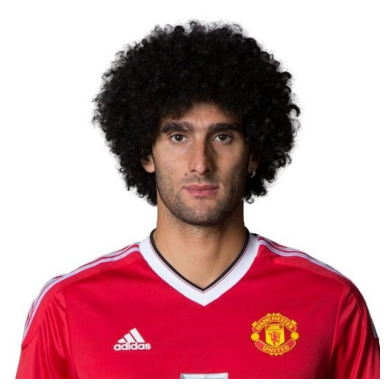

In [21]:
# 2. Görüntüyü göster (ilk hali)

plt.imshow(img_bonus_rgb)
plt.axis("off")

In [22]:
# Görüntüde ağırlıklı olarak, kişinin saçlarını (koyu siyah pikselleri) seçmek için aşağıdaki formülü yazıyoruz.
# Bu formülle koyu siyah piksellerin yani sıfıra çok yakın piksellerin görüntü üzerindeki koordinatlarını çıkarıyoruz.

In [23]:
# 3. Siyah pikselleri (saç gibi) turkuaz renge dönüştür
# Siyah piksel koşulu: R,G,B <= 40

koordinat_siyah = (img_bonus_rgb[:,:,0] <= 40) &  (img_bonus_rgb[:,:,1] <= 40) & (img_bonus_rgb[:,:,2] <= 40)

In [24]:
# Turkuaz renginin kodları = [0,255,255] yeşille mavinin değeri
img_bonus_rgb[koordinat_siyah] = [0,255 ,255]

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

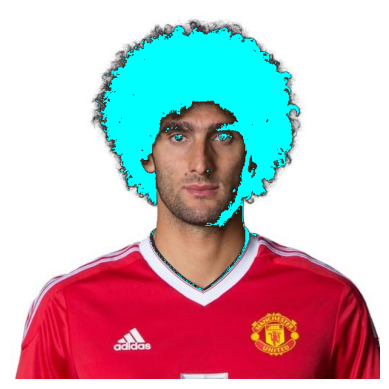

In [25]:
plt.imshow(img_bonus_rgb)
plt.axis("off")

In [26]:
# Futbolcunun tamamını (tüm bedenini) turkuaz renge dönüştürün

# İLK OLARAK görüntüdeki arka plan haricindeki tüm renkleri seç
# NOT : beyz rengin RGB kodları [255,255,255] olduğu için 
# <255 diyerek beyaz hariç tüm renkleri al demiş oluyoruz.


In [27]:
img_bonus_rgb_2 = cv2.cvtColor(img_bonus, cv2.COLOR_BGR2RGB)

In [28]:
koordinat_beyaz_haric = (img_bonus_rgb_2[:,:,0] < 255) &  (img_bonus_rgb_2[:,:,1] < 255) & (img_bonus_rgb_2[:,:,2] < 255)


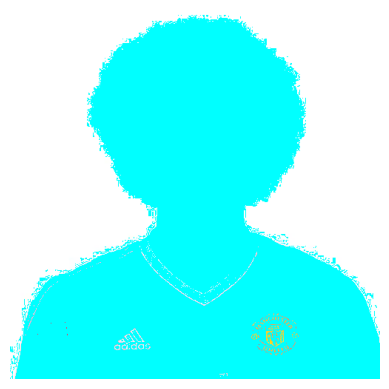

In [29]:
# Beyaz olmayan tüm pikselleri turkuaz renge dönüştür
# koordinat_beyaz_haric maskesi True olan pikseller seçilir
# Seçilen piksellerin RGB değeri [0,255,255] (turkuaz) olarak değiştirilir
img_bonus_rgb_2[koordinat_beyaz_haric] = [0,255,255]

# Değiştirilen görüntüyü ekranda göster
plt.imshow(img_bonus_rgb_2)
plt.axis("off")
plt.show()


In [30]:
# Kırmızı renkli formayı maviye dönüştürün
img_bonus_rgb_3 = cv2.cvtColor(img_bonus, cv2.COLOR_BGR2RGB)

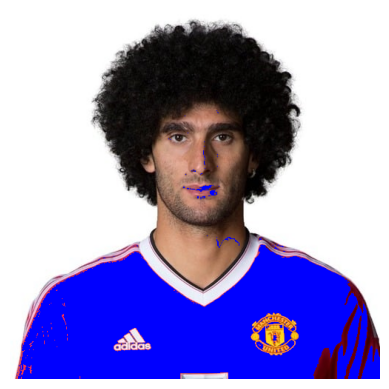

In [31]:
# Kırmızı renkli formayı maviye dönüştürün

# Görüntüyü oku ve BGR'den RGB'ye dönüştür
img_bonus_rgb_3 = cv2.cvtColor(img_bonus, cv2.COLOR_BGR2RGB)

# Kırmızı tonlarını bul:
# R kanalı yüksek, G ve B kanalları düşük olmalı
koordinat_kirmizi = (
    (img_bonus_rgb_3[:,:,0] > 120) &   # Kırmızı yoğunluğu yüksek
    (img_bonus_rgb_3[:,:,1] < 80)  &   # Yeşil düşük
    (img_bonus_rgb_3[:,:,2] < 80)      # Mavi düşük
)

# Kırmızı pikselleri maviye çevir (RGB'de mavi = [0, 0, 255])
img_bonus_rgb_3[koordinat_kirmizi] = [0, 0, 255]

# Görüntüyü göster
plt.imshow(img_bonus_rgb_3)
plt.axis("off")
plt.show()


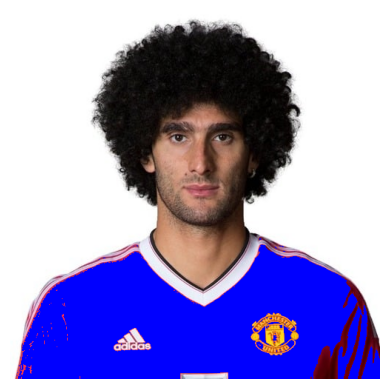

In [32]:
# Görüntüyü BGR (OpenCV formatı) yerine RGB formatına çeviriyoruz
# OpenCV varsayılan olarak BGR kullanır; matplotlib ile doğru renk görmek için RGB'ye çevirmek gerekir.
img_bonus_rgb_4 = cv2.cvtColor(img_bonus, cv2.COLOR_BGR2RGB)

# 300. satırdan itibaren görüntüdeki pikseller içinde "kırmızı tonlarını" bulmak için bir maske oluşturuyoruz.
# Burada 3 koşul var:
#   - R (kırmızı) kanalı 127'den büyük olmalı → kırmızı yoğunluğu yüksek.
#   - G (yeşil) kanalı 80'den küçük olmalı → yeşil katkısı düşük.
#   - B (mavi) kanalı 80'den küçük olmalı → mavi katkısı düşük.
# Yani bu koşullar, "kırmızı baskın" pikselleri (örneğin formayı) yakalamayı hedefler.
koordinat_kirmizi_2 = (
    (img_bonus_rgb_4[300:,:,0] > 127) &   # Kırmızı kanal değeri yüksek
    (img_bonus_rgb_4[300:,:,1] < 80)  &   # Yeşil kanal değeri düşük
    (img_bonus_rgb_4[300:,:,2] < 80)      # Mavi kanal değeri düşük
)

# Burada 300. satırdan sonraki kısımda, yukarıda oluşturulan maskeye uyan (True olan) pikselleri maviye boyuyoruz.
# DİKKAT ⚠️: "img_bonus_rgb_4[300:][mask]" kullanımı aslında doğrudan o pikselleri değiştirmeyebilir;
# Numpy bu durumda beklediğin gibi davranmayabilir (indeksleme farklı boyutlara uygulanır).
# Daha doğru yöntem: "bolge = img_bonus_rgb_4[300:,:,:]; bolge[mask] = [0,0,255]" şeklinde yapmaktır.
img_bonus_rgb_4[300:][koordinat_kirmizi_2] = [0,0,255]  # Kırmızı pikselleri maviye çevir

# Görüntüyü matplotlib ile ekranda gösteriyoruz.
# axis("off") → Eksen çizgilerini kaldırır, sadece resmi gösterir.
plt.imshow(img_bonus_rgb_4)
plt.axis("off")
plt.show()


In [36]:
# Aynı formülü sadece başın üst tarafından çenenin alt tarafına kadar geçerli olacak şekilde uygula.
# Yani, tüm görüntüye değil de görüntünün belli bir bölümüne 



In [37]:
# ÖZET: 

# - Var olan renkli görüntüler üzerinde renk seçme (masking) yapılabilir.
# - Belirli renkler (siyah, beyaz, kırmızı vb.) tespit edilip başka renklere dönüştürülebilir.
# - Renk değişiklikleri tüm görüntüye veya sadece seçili bölgelere uygulanabilir (bölgesel işlem).
# - Maske oluşturmak için RGB kanalları üzerinden koşullar kullanılır.
# - Siyah pikseller, beyaz hariç pikseller veya belirli renk tonları seçilebilir.
# - Numpy dizileri ile maskelenmiş pikseller kolayca değiştirilebilir.
# - Matplotlib ile işlenen görüntüler gösterilir, eksenler kapatılır ve renkler doğru biçimde görüntülenir.
# - Bu konu, özellikle eğitim, görsel analiz, spor ve grafik tasarım gibi alanlarda 
#   renk kontrolü ve görsel manipülasyon becerilerini geliştirmek için kullanılır.